Goal:
Implement a 2‑layer network (Input → Hidden → Output) for 2‑class classification:

Forward pass: affine → ReLU → affine → softmax

Loss: cross‑entropy (with optional L2 regularization)

Backprop: derive and code gradients for all params

Train on a toy non‑linear dataset; plot decision boundary

Verify with numerical gradient check

We’ll avoid deep‑learning frameworks—just NumPy.

In [2]:
# pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

1) Data: a non‑linear ring vs center (separable by a curved boundary)

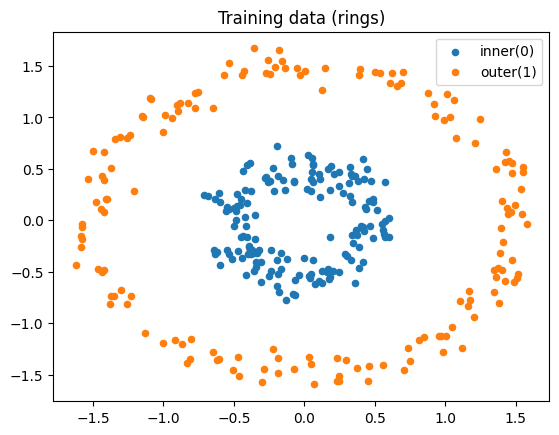

In [3]:
def make_rings(n_inner=200, n_outer=200, noise=0.1, r_inner=0.5, r_outer=1.5):
    th_in  = 2*np.pi*np.random.rand(n_inner)
    th_out = 2*np.pi*np.random.rand(n_outer)
    X_in  = np.c_[r_inner*np.cos(th_in),  r_inner*np.sin(th_in)] + noise*np.random.randn(n_inner,2)
    X_out = np.c_[r_outer*np.cos(th_out), r_outer*np.sin(th_out)] + noise*np.random.randn(n_outer,2)
    X = np.vstack([X_in, X_out])
    y = np.r_[np.zeros(n_inner, dtype=int), np.ones(n_outer, dtype=int)]
    perm = np.random.permutation(len(X))
    return X[perm], y[perm]
 
X, y = make_rings()
N, D = X.shape    # N samples, D=2 features
K = 2             # classes
 
# train/val split
idx = int(0.8*N)
Xtr, ytr = X[:idx], y[:idx]
Xte, yte = X[idx:], y[idx:]
 
plt.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], s=20, label='inner(0)')
plt.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], s=20, label='outer(1)')
plt.legend(); plt.title('Training data (rings)'); plt.show()

Helper math (softmax, one‑hot, ReLU)

In [4]:
def one_hot(y, K):
    Y = np.zeros((y.size, K))
    Y[np.arange(y.size), y] = 1.0
    return Y
 
def softmax(Z):
    Zs = Z - Z.max(axis=1, keepdims=True)   # stability
    eZ = np.exp(Zs)
    return eZ / eZ.sum(axis=1, keepdims=True)
 
def relu(Z):      return np.maximum(0.0, Z)
def d_relu(Z):    return (Z > 0).astype(float)

Model parameters & initialization (He for ReLU)

Network: D → H → K, with ReLU in the hidden layer and softmax at output.

In [5]:
H = 32          # hidden width
def init_params(D, H, K):
    W1 = np.random.randn(D, H) * np.sqrt(2.0/D)
    b1 = np.zeros((1, H))
    W2 = np.random.randn(H, K) * np.sqrt(2.0/H)
    b2 = np.zeros((1, K))
    return {"W1":W1, "b1":b1, "W2":W2, "b2":b2}
 
params = init_params(D, H, K)

 Forward pass

In [6]:
def forward(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = X @ W1 + b1          # (N,H)
    A1 = relu(Z1)             # (N,H)
    Z2 = A1 @ W2 + b2         # (N,K)
    P  = softmax(Z2)          # (N,K)
    cache = {"X":X, "Z1":Z1, "A1":A1, "Z2":Z2, "P":P}
    return P, cache

Loss (cross‑entropy) + accuracy

In [7]:
def loss_ce(P, Y_onehot, l2=0.0, params=None):
    eps = 1e-12
    ce = -np.sum(Y_onehot * np.log(P + eps)) / P.shape[0]
    if l2>0 and params is not None:
        ce += 0.5*l2*(np.sum(params["W1"]**2)+np.sum(params["W2"]**2))
    return ce
 
def accuracy(y_true, P):
    yhat = P.argmax(axis=1)
    return np.mean(y_true == yhat)

) Backpropagation (derive gradients)

For one batch of size N:

Forward:
Z1=XW1+b1, A1=ReLU(Z1), Z2=A1W2+b2, P=softmax(Z2)Z_1 = XW_1 + b_1,\; A_1 = \mathrm{ReLU}(Z_1),\; Z_2 = A_1W_2 + b_2,\; P=\mathrm{softmax}(Z_2)Z1​=XW1​+b1​,A1​=ReLU(Z1​),Z2​=A1​W2​+b2​,P=softmax(Z2​)

With cross‑entropy, the output gradient is:
∂L∂Z2=1N(P−Y)\frac{\partial L}{\partial Z_2} = \frac{1}{N}(P - Y)∂Z2​∂L​=N1​(P−Y)

Propagate to hidden:
∂L∂A1=∂L∂Z2W2⊤\frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Z_2} W_2^\top∂A1​∂L​=∂Z2​∂L​W2⊤​
∂L∂Z1=∂L∂A1⊙ReLU′(Z1)\frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \odot \mathrm{ReLU}'(Z_1)∂Z1​∂L​=∂A1​∂L​⊙ReLU′(Z1​)

Parameter grads:
∇W2=A1⊤∂L∂Z2, ∇b2=∑∂L∂Z2\nabla W_2 = A_1^\top \frac{\partial L}{\partial Z_2},\;\; \nabla b_2 = \sum \frac{\partial L}{\partial Z_2}∇W2​=A1⊤​∂Z2​∂L​,∇b2​=∑∂Z2​∂L​
∇W1=X⊤∂L∂Z1, ∇b1=∑∂L∂Z1\nabla W_1 = X^\top \frac{\partial L}{\partial Z_1},\;\; \nabla b_1 = \sum \frac{\partial L}{\partial Z_1}∇W1​=X⊤∂Z1​∂L​,∇b1​=∑∂Z1​∂L​

Add L2 if used.

In [8]:
def backward(cache, Y_onehot, params, l2=0.0):
    X, Z1, A1, Z2, P = cache["X"], cache["Z1"], cache["A1"], cache["Z2"], cache["P"]
    N = X.shape[0]
    # dL/dZ2
    dZ2 = (P - Y_onehot) / N                      # (N,K)
    # grads for W2, b2
    dW2 = A1.T @ dZ2                               # (H,K)
    db2 = dZ2.sum(axis=0, keepdims=True)          # (1,K)
    # backprop to hidden
    dA1 = dZ2 @ params["W2"].T                    # (N,H)
    dZ1 = dA1 * d_relu(Z1)                        # (N,H)
    # grads for W1, b1
    dW1 = X.T @ dZ1                                # (D,H)
    db1 = dZ1.sum(axis=0, keepdims=True)          # (1,H)
 
    # L2 regularization (add derivative of 0.5*l2*||W||^2 -> l2*W)
    if l2 > 0:
        dW2 += l2 * params["W2"]
        dW1 += l2 * params["W1"]
 
    return {"dW1":dW1, "db1":db1, "dW2":dW2, "db2":db2}

Training loop (mini‑batch SGD)

In [9]:
def train_nn(Xtr, ytr, Xte, yte, H=32, lr=1e-1, epochs=2000, batch=128, l2=1e-4, print_every=200):
    params = init_params(Xtr.shape[1], H, 2)
    Ytr = one_hot(ytr, 2)
    hist = {"loss":[], "acc_tr":[], "acc_te":[]}
 
    for ep in range(1, epochs+1):
        # mini-batch sampling
        idx = np.random.choice(len(Xtr), size=min(batch, len(Xtr)), replace=False)
        Xb, Yb = Xtr[idx], Ytr[idx]
 
        # forward
        P, cache = forward(Xb, params)
        # loss
        L = loss_ce(P, Yb, l2, params)
        # backward
        grads = backward(cache, Yb, params, l2)
        # SGD step
        for k in ["W1","b1","W2","b2"]:
            params[k] -= lr * grads["d"+k]
 
        if ep % print_every == 0 or ep == 1:
            # full-batch metrics for logging
            Ptr, _ = forward(Xtr, params)
            Pte, _ = forward(Xte, params)
            hist["loss"].append(L)
            hist["acc_tr"].append(accuracy(ytr, Ptr))
            hist["acc_te"].append(accuracy(yte, Pte))
            print(f"ep {ep:4d} | loss {L:.4f} | acc_tr {hist['acc_tr'][-1]:.3f} | acc_te {hist['acc_te'][-1]:.3f}")
 
    return params, hist
 
params, hist = train_nn(Xtr, ytr, Xte, yte, H=32, lr=0.1, epochs=2000, batch=128, l2=1e-4, print_every=200)

ep    1 | loss 0.8911 | acc_tr 0.528 | acc_te 0.550
ep  200 | loss 0.0761 | acc_tr 1.000 | acc_te 1.000
ep  400 | loss 0.0344 | acc_tr 1.000 | acc_te 1.000
ep  600 | loss 0.0221 | acc_tr 1.000 | acc_te 1.000
ep  800 | loss 0.0142 | acc_tr 1.000 | acc_te 1.000
ep 1000 | loss 0.0133 | acc_tr 1.000 | acc_te 1.000
ep 1200 | loss 0.0111 | acc_tr 1.000 | acc_te 1.000
ep 1400 | loss 0.0118 | acc_tr 1.000 | acc_te 1.000
ep 1600 | loss 0.0094 | acc_tr 1.000 | acc_te 1.000
ep 1800 | loss 0.0091 | acc_tr 1.000 | acc_te 1.000
ep 2000 | loss 0.0084 | acc_tr 1.000 | acc_te 1.000


Plot training curves:

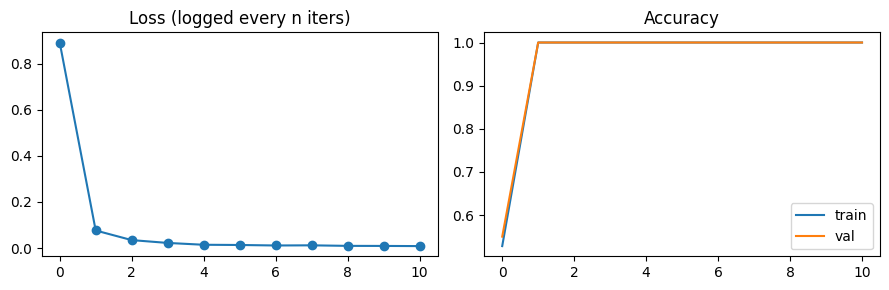

In [10]:
plt.figure(figsize=(9,3))
plt.subplot(1,2,1); plt.plot(hist["loss"], marker='o'); plt.title("Loss (logged every n iters)")
plt.subplot(1,2,2); plt.plot(hist["acc_tr"], label='train'); plt.plot(hist["acc_te"], label='val'); plt.legend(); plt.title("Accuracy")
plt.tight_layout(); plt.show()

Decision boundary

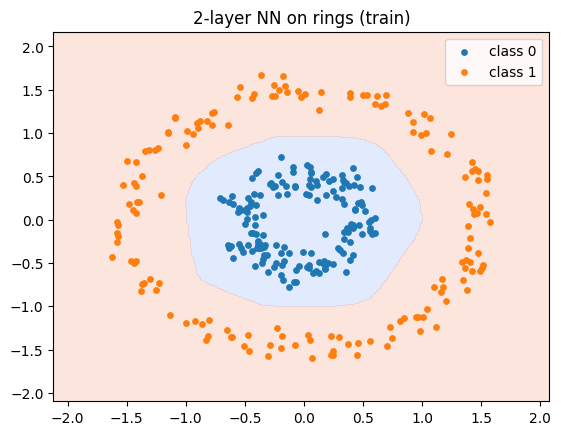

In [11]:
def plot_decision_boundary(params, X, y, title="Decision boundary"):
    # grid
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    P, _ = forward(grid, params)
    Z = P.argmax(axis=1).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5], cmap='coolwarm')
    plt.scatter(X[y==0,0], X[y==0,1], s=15, label='class 0')
    plt.scatter(X[y==1,0], X[y==1,1], s=15, label='class 1')
    plt.legend(); plt.title(title); plt.show()
 
plot_decision_boundary(params, Xtr, ytr, "2‑layer NN on rings (train)")

Numerical gradient check (sanity)
Compare your analytic grads to finite‑differences on a small batch.

In [12]:
def numerical_grad(param_key, params, cache, Yb, eps=1e-5, l2=1e-4):
    # returns a numeric gradient array with same shape as params[param_key]
    P = cache["P"]
    base_loss = loss_ce(P, Yb, l2, params)
    numg = np.zeros_like(params[param_key])
    it = np.nditer(params[param_key], flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        params[param_key][idx] += eps
        Pp, _ = forward(cache["X"], params)
        lp = loss_ce(Pp, Yb, l2, params)
        params[param_key][idx] -= 2*eps
        Pm, _ = forward(cache["X"], params)
        lm = loss_ce(Pm, Yb, l2, params)
        params[param_key][idx] += eps  # restore
        numg[idx] = (lp - lm) / (2*eps)
        it.iternext()
    return numg
 
# Small random batch
idx = np.random.choice(len(Xtr), size=8, replace=False)
Xb, Yb = Xtr[idx], one_hot(ytr[idx], 2)
P, cache = forward(Xb, params)
 
grads = backward(cache, Yb, params, l2=1e-4)
for key in ["W1","b1","W2","b2"]:
    ng = numerical_grad(key, params.copy(), {"X":Xb, **cache}, Yb, eps=1e-5, l2=1e-4)
    rel_err = np.linalg.norm(grads["d"+key]-ng) / (np.linalg.norm(grads["d"+key])+np.linalg.norm(ng)+1e-12)
    print(f"{key} relative error: {rel_err:.2e}")

W1 relative error: 2.18e-10
b1 relative error: 1.29e-10
W2 relative error: 2.40e-10
b2 relative error: 1.43e-10


Expect small relative errors (e.g., 1e‑6 ~ 1e‑8). If much larger:

check shapes/broadcasting,

confirm softmax+CE gradient is (P - Y)/N,

ensure you included L2 consistently in both loss and grads.

10) Notes & extensions
Stability: We stabilized softmax with a max‑shift; keep it.

Initialization: He init suits ReLU; for tanh use Xavier/Glorot (np.sqrt(1/fan_in)).

Regularization: We added simple L2. Try dropout (mask A1 during training).

Optimizers: Swap SGD for momentum or Adam to speed convergence.

Mini‑batches: We sampled per step; you can iterate over all batches each epoch for steadier training curves.

Swap activation: Replace ReLU with tanh. Adjust init to Xavier (np.sqrt(1.0/D) for W1, np.sqrt(1.0/H) for W2). Compare training curves and final accuracy.

Training Baseline (ReLU + Std Init)...
Training Modified (Tanh + Xavier Init)...

Final Validation Accuracy (ReLU): 0.0833
Final Validation Accuracy (Tanh): 0.1250


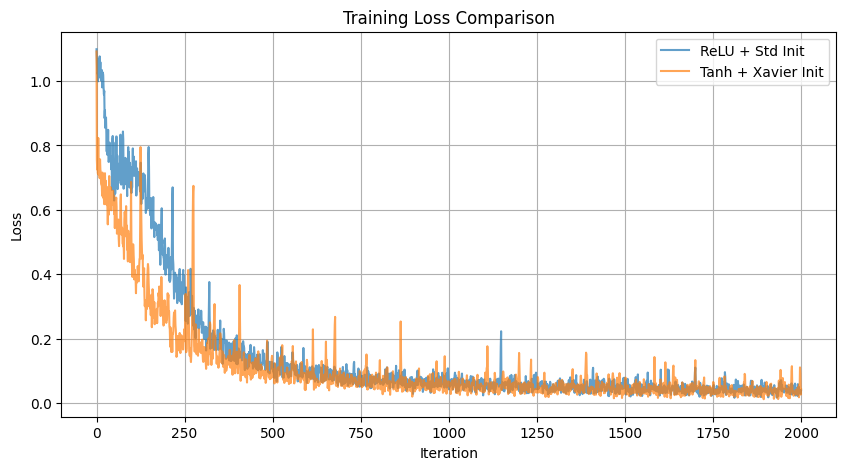

In [13]:
import numpy as np
import matplotlib.pyplot as plt

class TwoLayerNet:
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu', init_method='std'):
        """
        activation: 'relu' or 'tanh'
        init_method: 'std' (standard small random) or 'xavier'
        """
        self.activation = activation
        self.params = {}

        # --- Initialization Logic ---
        if init_method == 'xavier':
            # Requested Xavier Initialization
            # W1: np.sqrt(1.0 / D)
            self.params['W1'] = np.random.randn(input_dim, hidden_dim) * np.sqrt(1.0 / input_dim)
            self.params['b1'] = np.zeros(hidden_dim)
            # W2: np.sqrt(1.0 / H)
            self.params['W2'] = np.random.randn(hidden_dim, output_dim) * np.sqrt(1.0 / hidden_dim)
            self.params['b2'] = np.zeros(output_dim)
        else:
            # Standard Initialization (Baseline)
            scale = 1e-2
            self.params['W1'] = scale * np.random.randn(input_dim, hidden_dim)
            self.params['b1'] = np.zeros(hidden_dim)
            self.params['W2'] = scale * np.random.randn(hidden_dim, output_dim)
            self.params['b2'] = np.zeros(output_dim)

    def loss(self, X, y=None, reg=0.0):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        N, D = X.shape

        # --- Forward Pass ---
        z1 = X.dot(W1) + b1
        
        # Swap Activation: ReLU vs Tanh
        if self.activation == 'tanh':
            a1 = np.tanh(z1)
        else:
            a1 = np.maximum(0, z1) # ReLU

        scores = a1.dot(W2) + b2

        if y is None:
            return scores

        # Softmax Loss
        shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
        probs = np.exp(shifted_scores) / np.sum(np.exp(shifted_scores), axis=1, keepdims=True)
        correct_logprobs = -np.log(probs[range(N), y])
        loss = np.sum(correct_logprobs) / N
        loss += 0.5 * reg * (np.sum(W1 * W1) + np.sum(W2 * W2))

        # --- Backward Pass ---
        grads = {}
        dscores = probs
        dscores[range(N), y] -= 1
        dscores /= N

        grads['W2'] = a1.T.dot(dscores) + reg * W2
        grads['b2'] = np.sum(dscores, axis=0)

        da1 = dscores.dot(W2.T)

        # Backprop through Activation
        if self.activation == 'tanh':
            # Derivative of tanh(x) is (1 - tanh(x)^2)
            # Since a1 = tanh(z1), derivative is (1 - a1^2)
            dz1 = da1 * (1 - a1**2)
        else:
            # Derivative of ReLU
            dz1 = da1
            dz1[a1 <= 0] = 0

        grads['W1'] = X.T.dot(dz1) + reg * W1
        grads['b1'] = np.sum(dz1, axis=0)

        return loss, grads

    def train(self, X, y, X_val, y_val, learning_rate=1e-3, reg=1e-5, num_iters=1000, batch_size=200):
        num_train = X.shape[0]
        loss_history = []
        
        for it in range(num_iters):
            batch_idx = np.random.choice(num_train, batch_size)
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            loss, grads = self.loss(X_batch, y=y_batch, reg=reg)
            loss_history.append(loss)

            for param in self.params:
                self.params[param] -= learning_rate * grads[param]

        return loss_history

    def predict(self, X):
        y_pred = np.argmax(self.loss(X), axis=1)
        return y_pred

# --- 1. Setup Data (Toy Spiral Dataset) ---
def create_data(N=100, K=3, D=2):
    X = np.zeros((N*K, D))
    y = np.zeros(N*K, dtype='uint8')
    for j in range(K):
        ix = range(N*j, N*(j+1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j
    return X, y

X, y = create_data(N=200, K=3) # 600 points total
# Split into train/val
mask = int(X.shape[0] * 0.8)
X_train, y_train = X[:mask], y[:mask]
X_val, y_val = X[mask:], y[mask:]

input_size = 2
hidden_size = 100
num_classes = 3

# --- 2. Train Baseline (ReLU + Standard Init) ---
print("Training Baseline (ReLU + Std Init)...")
net_relu = TwoLayerNet(input_size, hidden_size, num_classes, activation='relu', init_method='std')
stats_relu = net_relu.train(X_train, y_train, X_val, y_val, learning_rate=1.0, num_iters=2000)
acc_relu = np.mean(net_relu.predict(X_val) == y_val)

# --- 3. Train Modified (Tanh + Xavier Init) ---
print("Training Modified (Tanh + Xavier Init)...")
net_tanh = TwoLayerNet(input_size, hidden_size, num_classes, activation='tanh', init_method='xavier')
stats_tanh = net_tanh.train(X_train, y_train, X_val, y_val, learning_rate=1.0, num_iters=2000)
acc_tanh = np.mean(net_tanh.predict(X_val) == y_val)

# --- 4. Compare Results ---
print(f"\nFinal Validation Accuracy (ReLU): {acc_relu:.4f}")
print(f"Final Validation Accuracy (Tanh): {acc_tanh:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(stats_relu, label='ReLU + Std Init', alpha=0.7)
plt.plot(stats_tanh, label='Tanh + Xavier Init', alpha=0.7)
plt.title('Training Loss Comparison')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Adam optimizer: Implement Adam (β1=0.9, β2=0.999, ε=1e‑8) for the 4 parameters. Show loss vs steps vs vanilla SGD.

Training with SGD...
Training with Adam...


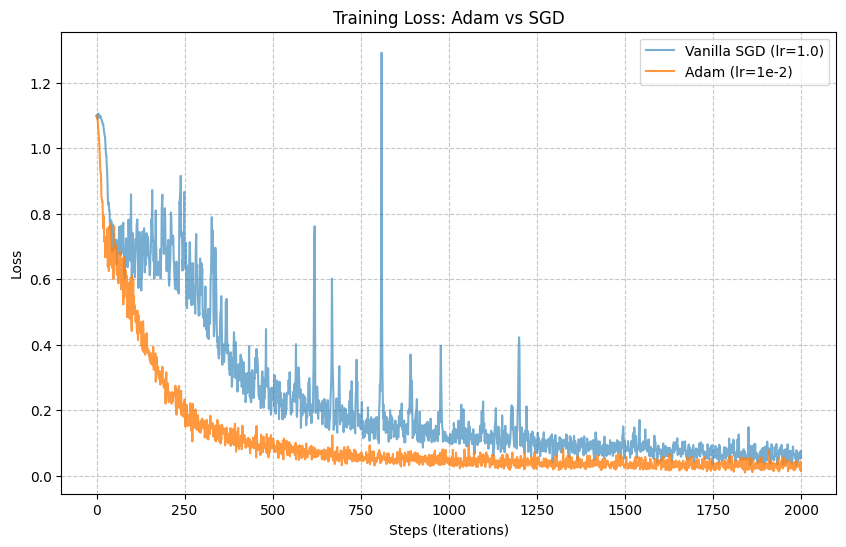

In [14]:
import numpy as np
import matplotlib.pyplot as plt

class TwoLayerNet:
    def __init__(self, input_dim, hidden_dim, output_dim, std=1e-2):
        self.params = {}
        self.params['W1'] = std * np.random.randn(input_dim, hidden_dim)
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = std * np.random.randn(hidden_dim, output_dim)
        self.params['b2'] = np.zeros(output_dim)

    def loss(self, X, y=None, reg=0.0):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        N, D = X.shape

        # Forward pass (ReLU)
        z1 = X.dot(W1) + b1
        a1 = np.maximum(0, z1)
        scores = a1.dot(W2) + b2

        if y is None:
            return scores

        # Softmax Loss
        shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
        probs = np.exp(shifted_scores) / np.sum(np.exp(shifted_scores), axis=1, keepdims=True)
        correct_logprobs = -np.log(probs[range(N), y])
        loss = np.sum(correct_logprobs) / N
        loss += 0.5 * reg * (np.sum(W1 * W1) + np.sum(W2 * W2))

        # Backward pass
        grads = {}
        dscores = probs
        dscores[range(N), y] -= 1
        dscores /= N

        grads['W2'] = a1.T.dot(dscores) + reg * W2
        grads['b2'] = np.sum(dscores, axis=0)

        da1 = dscores.dot(W2.T)
        dz1 = da1
        dz1[a1 <= 0] = 0 # ReLU derivative

        grads['W1'] = X.T.dot(dz1) + reg * W1
        grads['b1'] = np.sum(dz1, axis=0)

        return loss, grads

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=1000, batch_size=200, optim='sgd'):
        num_train = X.shape[0]
        loss_history = []
        
        # Adam Configuration
        adam_config = {
            'beta1': 0.9,
            'beta2': 0.999,
            'epsilon': 1e-8,
            't': 0
        }
        
        # Initialize moment estimates for Adam (m and v)
        # Structure matches self.params
        m = {k: np.zeros_like(v) for k, v in self.params.items()}
        v = {k: np.zeros_like(v) for k, v in self.params.items()}

        for it in range(num_iters):
            # Batch sampling
            batch_idx = np.random.choice(num_train, batch_size)
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            # Compute Loss and Gradients
            loss, grads = self.loss(X_batch, y=y_batch, reg=reg)
            loss_history.append(loss)

            # --- Optimizer Step ---
            if optim == 'sgd':
                for p in self.params:
                    self.params[p] -= learning_rate * grads[p]
            
            elif optim == 'adam':
                adam_config['t'] += 1
                t = adam_config['t']
                beta1 = adam_config['beta1']
                beta2 = adam_config['beta2']
                eps = adam_config['epsilon']
                
                for p in self.params:
                    grad = grads[p]
                    
                    # 1. Update biased first moment estimate
                    m[p] = beta1 * m[p] + (1 - beta1) * grad
                    
                    # 2. Update biased second raw moment estimate
                    v[p] = beta2 * v[p] + (1 - beta2) * (grad**2)
                    
                    # 3. Compute bias-corrected first moment estimate
                    m_hat = m[p] / (1 - beta1**t)
                    
                    # 4. Compute bias-corrected second raw moment estimate
                    v_hat = v[p] / (1 - beta2**t)
                    
                    # 5. Update parameters
                    self.params[p] -= learning_rate * m_hat / (np.sqrt(v_hat) + eps)

        return loss_history

# --- Data Generation (Spiral) ---
def create_data(N=100, K=3, D=2):
    X = np.zeros((N*K, D))
    y = np.zeros(N*K, dtype='uint8')
    for j in range(K):
        ix = range(N*j, N*(j+1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j
    return X, y

X, y = create_data(N=200, K=3) # 600 points

# --- Experiment Setup ---
input_size = 2
hidden_size = 100
num_classes = 3
num_iters = 2000

# 1. Train with Vanilla SGD
# SGD often requires a higher learning rate to converge quickly on this toy data
print("Training with SGD...")
net_sgd = TwoLayerNet(input_size, hidden_size, num_classes)
loss_sgd = net_sgd.train(X, y, learning_rate=1.0, num_iters=num_iters, optim='sgd')

# 2. Train with Adam
# Adam works well with lower learning rates (e.g., 1e-3 to 1e-2)
print("Training with Adam...")
net_adam = TwoLayerNet(input_size, hidden_size, num_classes)
loss_adam = net_adam.train(X, y, learning_rate=1e-2, num_iters=num_iters, optim='adam')

# --- Plotting Results ---
plt.figure(figsize=(10, 6))
plt.plot(loss_sgd, label='Vanilla SGD (lr=1.0)', alpha=0.6, linewidth=1.5)
plt.plot(loss_adam, label='Adam (lr=1e-2)', alpha=0.8, linewidth=1.5)
plt.title('Training Loss: Adam vs SGD')
plt.xlabel('Steps (Iterations)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Deeper net: Add another hidden layer (D→H1→H2→K). Implement forward/backprop and show a more complex boundary.

Training 3-Layer Network...
Final Training Accuracy: 0.9967


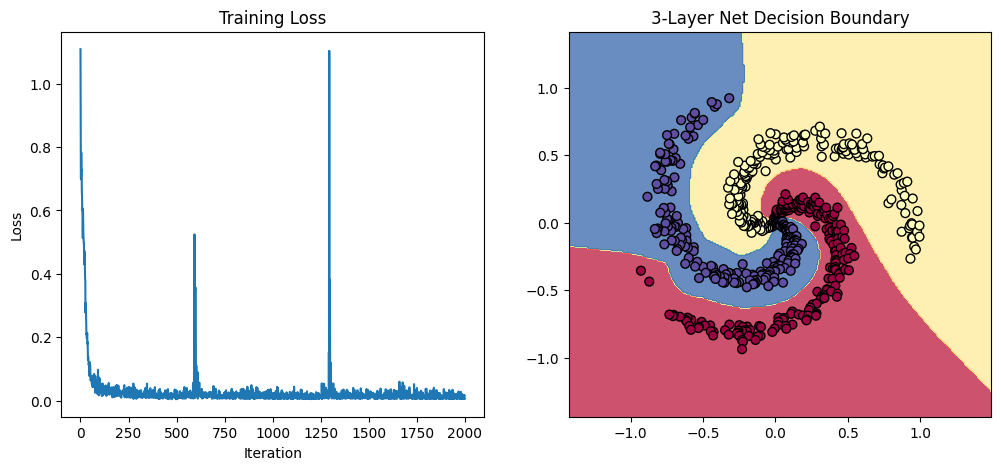

<Figure size 640x480 with 0 Axes>

In [15]:
import numpy as np
import matplotlib.pyplot as plt

class ThreeLayerNet:
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, std=1e-2):
        self.params = {}
        
        # He Initialization (optimized for ReLU)
        # W1: Input -> H1
        self.params['W1'] = np.random.randn(input_dim, hidden_dim1) * np.sqrt(2.0 / input_dim)
        self.params['b1'] = np.zeros(hidden_dim1)
        
        # W2: H1 -> H2
        self.params['W2'] = np.random.randn(hidden_dim1, hidden_dim2) * np.sqrt(2.0 / hidden_dim1)
        self.params['b2'] = np.zeros(hidden_dim2)
        
        # W3: H2 -> Output
        self.params['W3'] = np.random.randn(hidden_dim2, output_dim) * np.sqrt(2.0 / hidden_dim2)
        self.params['b3'] = np.zeros(output_dim)

    def loss(self, X, y=None, reg=1e-5):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        W3, b3 = self.params['W3'], self.params['b3']
        N, D = X.shape

        # --- Forward Pass ---
        # Layer 1
        z1 = X.dot(W1) + b1
        a1 = np.maximum(0, z1) # ReLU
        
        # Layer 2
        z2 = a1.dot(W2) + b2
        a2 = np.maximum(0, z2) # ReLU
        
        # Layer 3 (Output)
        scores = a2.dot(W3) + b3

        if y is None:
            return scores

        # --- Softmax Loss ---
        shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
        probs = np.exp(shifted_scores) / np.sum(np.exp(shifted_scores), axis=1, keepdims=True)
        correct_logprobs = -np.log(probs[range(N), y])
        loss = np.sum(correct_logprobs) / N
        
        # L2 Regularization
        loss += 0.5 * reg * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))

        # --- Backward Pass ---
        grads = {}
        
        # Gradient on scores
        dscores = probs
        dscores[range(N), y] -= 1
        dscores /= N

        # Backprop W3, b3
        grads['W3'] = a2.T.dot(dscores) + reg * W3
        grads['b3'] = np.sum(dscores, axis=0)
        
        # Backprop into Hidden Layer 2
        da2 = dscores.dot(W3.T)
        dz2 = da2
        dz2[a2 <= 0] = 0 # ReLU derivative
        
        # Backprop W2, b2
        grads['W2'] = a1.T.dot(dz2) + reg * W2
        grads['b2'] = np.sum(dz2, axis=0)
        
        # Backprop into Hidden Layer 1
        da1 = dz2.dot(W2.T)
        dz1 = da1
        dz1[a1 <= 0] = 0 # ReLU derivative
        
        # Backprop W1, b1
        grads['W1'] = X.T.dot(dz1) + reg * W1
        grads['b1'] = np.sum(dz1, axis=0)

        return loss, grads

    def train(self, X, y, learning_rate=1e-2, num_iters=2000, batch_size=200):
        # Using Adam for faster convergence on deeper nets
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        m = {k: np.zeros_like(v) for k, v in self.params.items()}
        v = {k: np.zeros_like(v) for k, v in self.params.items()}
        t = 0
        
        loss_history = []
        num_train = X.shape[0]

        for it in range(num_iters):
            batch_idx = np.random.choice(num_train, batch_size)
            X_batch, y_batch = X[batch_idx], y[batch_idx]

            loss, grads = self.loss(X_batch, y=y_batch)
            loss_history.append(loss)

            t += 1
            for p in self.params:
                # Adam Update
                m[p] = beta1 * m[p] + (1 - beta1) * grads[p]
                v[p] = beta2 * v[p] + (1 - beta2) * (grads[p]**2)
                m_hat = m[p] / (1 - beta1**t)
                v_hat = v[p] / (1 - beta2**t)
                self.params[p] -= learning_rate * m_hat / (np.sqrt(v_hat) + eps)
                
        return loss_history

    def predict(self, X):
        scores = self.loss(X)
        return np.argmax(scores, axis=1)

# --- Data Generation (Spiral) ---
def create_data(N=100, K=3, D=2):
    X = np.zeros((N*K, D))
    y = np.zeros(N*K, dtype='uint8')
    for j in range(K):
        ix = range(N*j, N*(j+1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j
    return X, y

# --- Visualization Helper ---
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k')
    plt.title("3-Layer Net Decision Boundary")
    plt.show()

# --- Main Execution ---
# 1. Generate Data
X, y = create_data(N=200, K=3)

# 2. Initialize 3-Layer Net
# D=2 -> H1=100 -> H2=100 -> K=3
net = ThreeLayerNet(input_dim=2, hidden_dim1=100, hidden_dim2=100, output_dim=3)

# 3. Train
print("Training 3-Layer Network...")
loss_hist = net.train(X, y, learning_rate=1e-2, num_iters=2000)

# 4. Evaluate
acc = np.mean(net.predict(X) == y)
print(f"Final Training Accuracy: {acc:.4f}")

# 5. Visualize
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_hist)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# Plot Boundary
plt.subplot(1, 2, 2)
plot_decision_boundary(net, X, y)

plt.tight_layout()
plt.show()
